# Notebook 06: Option Pricing — CHMM vs Heston Benchmark

This notebook prices European options using two Monte Carlo frameworks:

1. **CHMM regime-switching volatility** — a trained continuous HMM on VIX data maps volatility regimes to equity vol.
2. **Heston stochastic volatility** — the classical SV benchmark with mean-reverting variance.

We compare ATM call prices, examine MC convergence, and compute implied volatility surfaces.

### Outputs
- ATM call price comparison (CHMM vs Heston vs Black-Scholes)
- Monte Carlo convergence diagnostics
- Implied volatility surface heatmaps

## Setup

In [1]:
include("../Include.jl");

## Configuration

All tunable parameters are collected here for easy experimentation.

In [2]:
# --- TUNABLE PARAMETERS ---
K_vix = 6;                  # number of VIX hidden states
MAX_ITER = 60;              # Baum-Welch iterations for VIX CHMM
n_mc_paths = 10000;         # Monte Carlo paths for pricing
S0 = 580.0;                 # spot price (SPY-like)
strike = 580.0;             # ATM strike
T_expiry = 0.25;            # time to expiry (years)
r = 0.05;                   # risk-free rate
Δt = 1/252;                 # daily time step
risk_free_rate = 0.0;       # for returns computation

## Train VIX CHMM

Load VIX price data, compute log returns, and train a continuous HMM on VIX returns.
The learned regimes capture distinct volatility environments (calm, elevated, crisis).

In [3]:
# --- LOAD VIX DATA ---
vix_dataset_raw = MyVolatilityDataSet() |> x -> x["dataset"];
vix_ticker = first(keys(vix_dataset_raw));
vix_df = vix_dataset_raw[vix_ticker];
println("VIX ticker key: $(vix_ticker), rows: $(nrow(vix_df))");

VIX ticker key: VIX, rows: 4714


In [4]:
# --- COMPUTE VIX RETURNS ---
vix_close = vix_df.close;
vix_returns = log_growth_matrix(Float64.(vix_close); Δt=Δt, risk_free_rate=risk_free_rate);
println("VIX returns: $(length(vix_returns)) observations");
println("  mean = $(round(mean(vix_returns), digits=4)), std = $(round(std(vix_returns), digits=4))");

VIX returns: 4713 observations
  mean = 0.0189, std = 19.2705


In [5]:
# --- TRAIN CHMM ON VIX ---
vix_hmm = build(MyContinuousHiddenMarkovModel, (
    observations = vix_returns,
    number_of_states = K_vix,
    max_iter = MAX_ITER
));

println("VIX CHMM trained: K=$(K_vix), $(length(vix_hmm.log_likelihood_history)) EM iterations");
println("  Final log-likelihood: $(round(last(vix_hmm.log_likelihood_history), digits=2))");

# Print emission parameters
for s in vix_hmm.states
    d = vix_hmm.emission[s];
    println("  State $s: μ=$(round(mean(d), digits=4)), σ=$(round(std(d), digits=4))");
end

VIX CHMM trained: K=6, 60 EM iterations
  Final log-likelihood: -19959.79
  State 1: μ=-14.016, σ=11.106
  State 2: μ=-11.3191, σ=7.0621
  State 3: μ=-4.3561, σ=4.024
  State 4: μ=3.1602, σ=4.9543
  State 5: μ=13.0426, σ=11.2738
  State 6: μ=5.9922, σ=33.7183


## Decode VIX Regimes

Apply the Viterbi algorithm to recover the most likely hidden state sequence for VIX returns.
This decoded sequence, together with VIX price levels, builds the volatility map.

In [6]:
# --- VITERBI DECODE ---
vix_states = viterbi(vix_returns, vix_hmm);
println("Decoded $(length(vix_states)) VIX states across $(K_vix) regimes");

# State frequency
for s in sort(unique(vix_states))
    count_s = sum(vix_states .== s);
    println("  State $s: $(count_s) days ($(round(100*count_s/length(vix_states), digits=1))%)");
end

Decoded 4713 VIX states across 6 regimes
  State 1: 295 days (6.3%)
  State 2: 837 days (17.8%)
  State 3: 708 days (15.0%)
  State 4: 977 days (20.7%)
  State 5: 642 days (13.6%)
  State 6: 1254 days (26.6%)


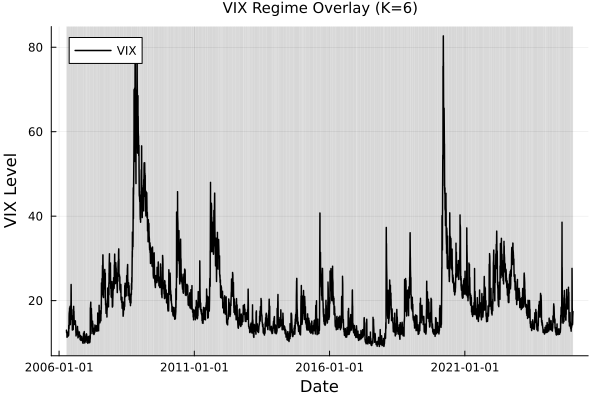

LoadError: SystemError: opening file "/Users/abdulrahmanalswaidan/Desktop/Project-Repos/HMM-withJumps-WIP/figs/Fig-VIX-Regime-Overlay-K6.svg": No such file or directory

In [7]:
# --- PLOT: VIX REGIME OVERLAY ---
# Align VIX prices with returns (returns start at day 2)
vix_prices_aligned = Float64.(vix_close[2:end]);
vix_dates = vix_df.date[2:end];

fig_regimes = plot_regime_overlay(vix_dates, vix_prices_aligned, vix_states, "VIX";
    title_text="VIX Regime Overlay (K=$(K_vix))");
xlabel!(fig_regimes, "Date");
display(fig_regimes);

savefig(fig_regimes, joinpath(_PATH_TO_FIGURES, "Fig-VIX-Regime-Overlay-K$(K_vix).svg"));

## Build CHMM Pricer

The `MyCHMMPricingModel` maps VIX regime levels to equity volatility via:

$$\sigma_s = \frac{\text{median}(\text{VIX}_{\text{close}} \mid \text{state} = s)}{100}$$

This bridges the VIX-trained HMM to an equity option pricing engine.

In [8]:
# --- BUILD CHMM PRICER ---
chmm_pricer = build(MyCHMMPricingModel, (
    hmm = vix_hmm,
    vix_prices = vix_prices_aligned,
    vix_states = vix_states,
    n_paths = n_mc_paths,
    n_steps_per_year = 252
));

println("CHMM Pricer built: $(n_mc_paths) paths, 252 steps/year");
println("Volatility map (VIX regime → equity σ):");
for s in sort(collect(keys(chmm_pricer.volatility_map)))
    println("  State $s → σ = $(round(chmm_pricer.volatility_map[s], digits=4)) ($(round(chmm_pricer.volatility_map[s]*100, digits=2))%)");
end

CHMM Pricer built: 10000 paths, 252 steps/year
Volatility map (VIX regime → equity σ):
  State 1 → σ = 0.1769 (17.69%)
  State 2 → σ = 0.1609 (16.09%)
  State 3 → σ = 0.1522 (15.22%)
  State 4 → σ = 0.15 (15.0%)
  State 5 → σ = 0.1697 (16.97%)
  State 6 → σ = 0.2049 (20.49%)


## Build Heston Pricer

The Heston model provides a stochastic volatility benchmark:

$$dS = rS\,dt + \sqrt{v}\,S\,dW_1$$
$$dv = \kappa(\theta - v)\,dt + \xi\sqrt{v}\,dW_2$$
$$\text{corr}(dW_1, dW_2) = \rho$$

In [9]:
# --- BUILD HESTON PRICER ---
heston_pricer = build(MyHestonPricingModel, (
    v0 = 0.04,              # initial variance (vol ≈ 20%)
    kappa = 2.0,            # mean reversion speed
    theta = 0.04,           # long-run variance
    xi = 0.3,               # vol-of-vol
    rho = -0.7,             # price-vol correlation (leverage effect)
    n_paths = n_mc_paths,
    n_steps_per_year = 252
));

println("Heston Pricer built: v0=$(heston_pricer.v0), κ=$(heston_pricer.kappa), θ=$(heston_pricer.theta), ξ=$(heston_pricer.xi), ρ=$(heston_pricer.rho)");

Heston Pricer built: v0=0.04, κ=2.0, θ=0.04, ξ=0.3, ρ=-0.7


## Build European Option Contract

In [10]:
# --- BUILD CONTRACT ---
contract = build(MyEuropeanOptionContract, (
    S0 = S0,
    K = strike,
    T = T_expiry,
    r = r,
    is_call = true
));

println("European Call Option:");
println("  S0 = \$$(contract.S0), K = \$$(contract.K), T = $(contract.T) yr, r = $(contract.r)");

European Call Option:
  S0 = $580.0, K = $580.0, T = 0.25 yr, r = 0.05


## Price ATM Call

Price the ATM call under all three approaches:
1. **CHMM** — regime-switching Monte Carlo
2. **Heston** — stochastic volatility Monte Carlo
3. **Black-Scholes** — analytical benchmark at historical vol

In [11]:
# --- PRICE WITH CHMM ---
Random.seed!(42);
chmm_result = price(chmm_pricer, contract);
println("CHMM Price:   \$$(round(chmm_result.price, digits=4)) ± \$$(round(1.96*chmm_result.std_error, digits=4)) (95% CI)");

CHMM Price:   $23.4636 ± $0.6512 (95% CI)


In [12]:
# --- PRICE WITH HESTON ---
Random.seed!(42);
heston_result = price(heston_pricer, contract);
println("Heston Price: \$$(round(heston_result.price, digits=4)) ± \$$(round(1.96*heston_result.std_error, digits=4)) (95% CI)");

Heston Price: $26.8258 ± $0.6653 (95% CI)


In [13]:
# --- BLACK-SCHOLES BENCHMARK ---
# Use weighted-average CHMM vol as the "historical" sigma for BS
π_stat = chmm_pricer.start_distribution.p;
σ_hist = sum(π_stat[s] * chmm_pricer.volatility_map[s] for s in vix_hmm.states);
bs_price = black_scholes(contract, σ_hist);

println("Black-Scholes Price: \$$(round(bs_price, digits=4)) (σ_hist = $(round(σ_hist*100, digits=2))%)");

Black-Scholes Price: $23.406 (σ_hist = 17.05%)


In [14]:
# --- SUMMARY TABLE ---
println("\n" * "="^60);
println("ATM Call Pricing Summary (S0=\$$(S0), K=\$$(strike), T=$(T_expiry)yr)");
println("="^60);
println("Model          | Price      | Std Error  | 95% CI");
println("-"^60);
println("CHMM           | \$$(lpad(round(chmm_result.price, digits=4), 9))  | \$$(lpad(round(chmm_result.std_error, digits=4), 8))  | ±\$$(round(1.96*chmm_result.std_error, digits=4))");
println("Heston         | \$$(lpad(round(heston_result.price, digits=4), 9))  | \$$(lpad(round(heston_result.std_error, digits=4), 8))  | ±\$$(round(1.96*heston_result.std_error, digits=4))");
println("Black-Scholes  | \$$(lpad(round(bs_price, digits=4), 9))  |     ---    |    ---");
println("="^60);


ATM Call Pricing Summary (S0=$580.0, K=$580.0, T=0.25yr)
Model          | Price      | Std Error  | 95% CI
------------------------------------------------------------
CHMM           | $  23.4636  | $  0.3322  | ±$0.6512
Heston         | $  26.8258  | $  0.3394  | ±$0.6653
Black-Scholes  | $   23.406  |     ---    |    ---


## Comparison Bar Chart

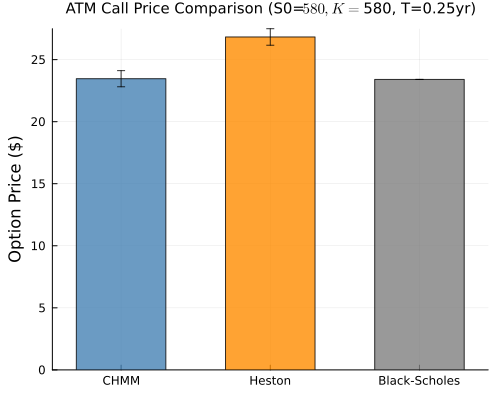

LoadError: SystemError: opening file "/Users/abdulrahmanalswaidan/Desktop/Project-Repos/HMM-withJumps-WIP/figs/Fig-Option-Pricing-Comparison.svg": No such file or directory

In [15]:
# --- FIGURE: PRICING COMPARISON ---
fig_comparison = plot_pricing_comparison(chmm_result, heston_result, bs_price,
    "ATM Call Price Comparison (S0=\$$(Int(S0)), K=\$$(Int(strike)), T=$(T_expiry)yr)");
display(fig_comparison);

savefig(fig_comparison, joinpath(_PATH_TO_FIGURES, "Fig-Option-Pricing-Comparison.svg"));

## Monte Carlo Convergence

The running average of discounted payoffs should stabilize as the number of paths grows.
A smooth convergence curve indicates adequate path count.

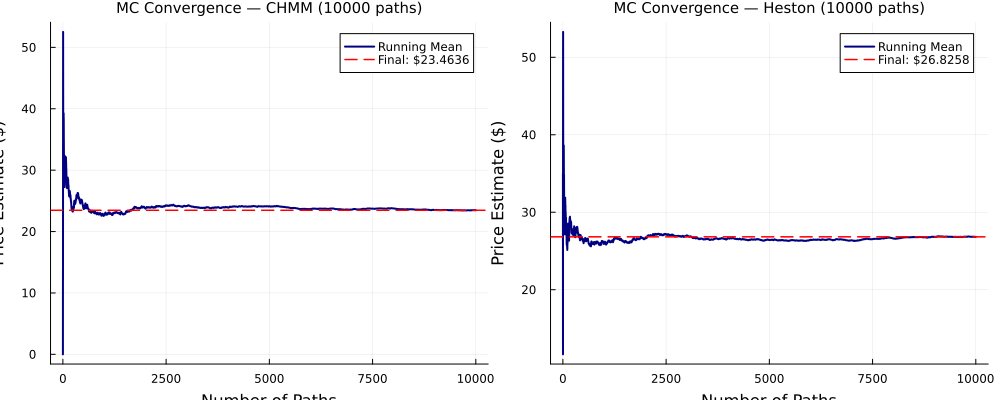

LoadError: SystemError: opening file "/Users/abdulrahmanalswaidan/Desktop/Project-Repos/HMM-withJumps-WIP/figs/Fig-Option-MC-Convergence.svg": No such file or directory

In [16]:
# --- FIGURE: MC CONVERGENCE ---
fig_conv_chmm = plot_mc_convergence(chmm_result, "MC Convergence — CHMM ($(n_mc_paths) paths)");
fig_conv_heston = plot_mc_convergence(heston_result, "MC Convergence — Heston ($(n_mc_paths) paths)");

fig_convergence = plot(fig_conv_chmm, fig_conv_heston, layout=(1, 2), size=(1000, 400));
display(fig_convergence);

savefig(fig_convergence, joinpath(_PATH_TO_FIGURES, "Fig-Option-MC-Convergence.svg"));

## Implied Volatility Surface

Compute the implied volatility surface over a grid of strikes and expiries.
Each grid point is priced via Monte Carlo and then inverted through Black-Scholes.

The CHMM surface should exhibit regime-induced smile/skew structure,
while Heston produces the classical leverage-driven skew.

In [17]:
# --- DEFINE STRIKE/EXPIRY GRID ---
strikes = collect(range(0.90 * S0, 1.10 * S0, length=7));
expiries = [0.08, 0.17, 0.25, 0.50, 0.75, 1.0];

println("IV surface grid: $(length(strikes)) strikes x $(length(expiries)) expiries = $(length(strikes)*length(expiries)) contracts");
println("  Strikes: $(round.(strikes, digits=1))");
println("  Expiries: $(expiries)");

IV surface grid: 7 strikes x 6 expiries = 42 contracts
  Strikes: [522.0, 541.3, 560.7, 580.0, 599.3, 618.7, 638.0]
  Expiries: [0.08, 0.17, 0.25, 0.5, 0.75, 1.0]


In [18]:
# --- COMPUTE CHMM IV SURFACE ---
println("Computing CHMM implied vol surface...");
Random.seed!(123);
iv_chmm = implied_vol_surface(chmm_pricer, S0, r, strikes, expiries; is_call=true);
println("  Done. IV range: $(round(minimum(iv_chmm)*100, digits=1))% — $(round(maximum(iv_chmm)*100, digits=1))%");

Computing CHMM implied vol surface...
  Done. IV range: 0.0% — 18.3%


In [19]:
# --- COMPUTE HESTON IV SURFACE ---
println("Computing Heston implied vol surface...");
Random.seed!(123);
iv_heston = implied_vol_surface(heston_pricer, S0, r, strikes, expiries; is_call=true);
println("  Done. IV range: $(round(minimum(iv_heston)*100, digits=1))% — $(round(maximum(iv_heston)*100, digits=1))%");

Computing Heston implied vol surface...
  Done. IV range: 16.2% — 23.1%


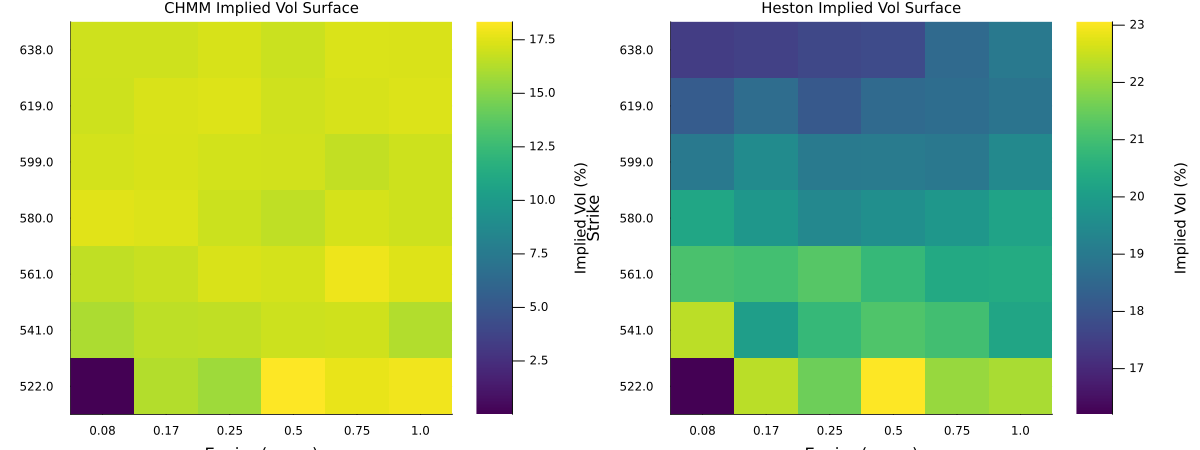

LoadError: SystemError: opening file "/Users/abdulrahmanalswaidan/Desktop/Project-Repos/HMM-withJumps-WIP/figs/Fig-Implied-Vol-Surface-CHMM-vs-Heston.svg": No such file or directory

In [20]:
# --- FIGURE: IV SURFACE HEATMAPS ---
fig_iv_chmm = plot_implied_vol_surface(strikes, expiries, iv_chmm,
    "CHMM Implied Vol Surface");
fig_iv_heston = plot_implied_vol_surface(strikes, expiries, iv_heston,
    "Heston Implied Vol Surface");

fig_iv = plot(fig_iv_chmm, fig_iv_heston, layout=(1, 2), size=(1200, 450));
display(fig_iv);

savefig(fig_iv, joinpath(_PATH_TO_FIGURES, "Fig-Implied-Vol-Surface-CHMM-vs-Heston.svg"));

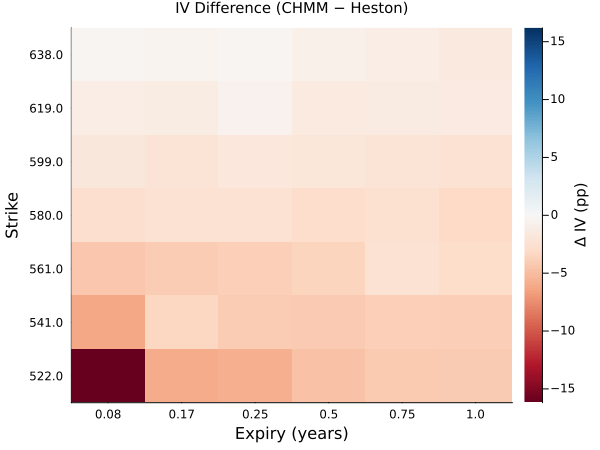

LoadError: SystemError: opening file "/Users/abdulrahmanalswaidan/Desktop/Project-Repos/HMM-withJumps-WIP/figs/Fig-IV-Difference-CHMM-Heston.svg": No such file or directory

In [21]:
# --- IV DIFFERENCE HEATMAP ---
iv_diff = (iv_chmm .- iv_heston) .* 100;  # in percentage points

strike_labels = [string(round(k, digits=0)) for k in strikes];
expiry_labels = [string(round(t, digits=2)) for t in expiries];

fig_iv_diff = heatmap(expiry_labels, strike_labels, iv_diff,
    title="IV Difference (CHMM − Heston)", titlefontsize=10,
    xlabel="Expiry (years)", ylabel="Strike",
    color=:RdBu, colorbar_title="Δ IV (pp)",
    clims=(-maximum(abs.(iv_diff)), maximum(abs.(iv_diff))),
    size=(600, 450));
display(fig_iv_diff);

savefig(fig_iv_diff, joinpath(_PATH_TO_FIGURES, "Fig-IV-Difference-CHMM-Heston.svg"));

## Disclaimer

This content is offered solely for research and educational purposes. It does not constitute financial advice.
Option prices are simulated under simplified assumptions and should not be used for live trading decisions.